In [1]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

In [2]:
df = pd.read_csv('../data/financial_phrasebank.csv')
df

,sentence,label,label_name
0,"According to Gran , the company has no plans t...",1,Neutral
1,"For the last quarter of 2010 , Componenta 's n...",2,Positive
2,"In the third quarter of 2010 , net sales incre...",2,Positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,2,Positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",2,Positive
...,...,...,...
2259,Operating result for the 12-month period decre...,0,Negative
2260,HELSINKI Thomson Financial - Shares in Cargote...,0,Negative
2261,LONDON MarketWatch -- Share prices ended lower...,0,Negative
2262,Operating profit fell to EUR 35.4 mn from EUR ...,0,Negative


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df['sentence'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Training phrases: {len(X_train)}")
print(f"Test phrases: {len(X_test)}")

Training phrases: 1811
Test phrases: 453


In [4]:
tf_idf = TfidfVectorizer(stop_words='english', max_features=2000)

In [5]:
X_train_tf_idf = tf_idf.fit_transform(X_train)

X_test_tf_idf = tf_idf.transform(X_test)

print("Done")
print(f"Size of training matrix (Phrases, Word): {X_train_tf_idf.shape}")

Done
Size of training matrix (Phrases, Word): (1811, 2000)


In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
nb_model = MultinomialNB()

In [8]:
nb_model.fit(X_train_tf_idf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [9]:
y_pred = nb_model.predict(X_test_tf_idf)

In [10]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}\n")
print("Detail:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

Accuracy: 0.79

Detail:
              precision    recall  f1-score   support

    Negative       1.00      0.10      0.18        61
     Neutral       0.88      0.94      0.91       278
    Positive       0.59      0.77      0.67       114

    accuracy                           0.79       453
   macro avg       0.82      0.60      0.59       453
weighted avg       0.82      0.79      0.75       453



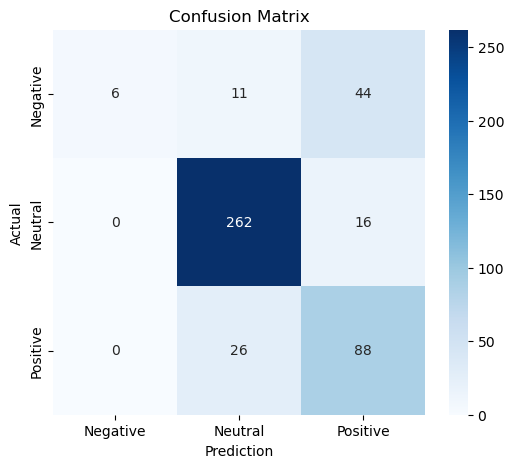

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [12]:
def news_forecast(phrases):
    vectorized_phrases = tf_idf.transform([phrases])

    prediction = nb_model.predict(vectorized_phrases)[0]
    probability = nb_model.predict_proba(vectorized_phrases).max()

    print(f"News: '{phrases}'")
    print(f"Emotion: {prediction} (Reliability: {probability:.2f})")
    print("-" * 30)

In [13]:
# Positive news
news_forecast("Gold price hits record high as investors seek safety.")

# Negative news
news_forecast("Company reports massive loss due to supply chain issues.")

# Neutral news
news_forecast("The board of directors will meet on Friday.")

# Trap
news_forecast("The profit is not good.")

News: 'Gold price hits record high as investors seek safety.'
Emotion: 1 (Reliability: 0.67)
------------------------------
News: 'Company reports massive loss due to supply chain issues.'
Emotion: 2 (Reliability: 0.55)
------------------------------
News: 'The board of directors will meet on Friday.'
Emotion: 1 (Reliability: 0.82)
------------------------------
News: 'The profit is not good.'
Emotion: 2 (Reliability: 0.55)
------------------------------


In [14]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [15]:
MAX_WORDS = 5000
MAX_LEN = 50

In [16]:
tokennizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokennizer.fit_on_texts(df['sentence'])

In [17]:
word_index = tokennizer.word_index
print(f"Found {len(word_index)} unique word.")

Found 6110 unique word.


In [18]:
sequences = tokennizer.texts_to_sequences(df['sentence'])

In [19]:
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = to_categorical(df['label'])

In [20]:
from sklearn.model_selection import train_test_split
X_train_seq, X_test_seg, y_train_seq, y_test_seg = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
print("\nData ready.")
print(f"X_train shape: {X_train_seq.shape}")
print(f"y_train shape: {y_train_seq.shape}")
print(f"First sentence:\n {X_train_seq[0]}")


Data ready.
X_train shape: (1811, 50)
y_train shape: (1811, 3)
First sentence:
 [   8   87    3 2472   22   15   26 1162    4    2  174    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


EMBEDDING_DIM = 64

model = Sequential()

model.add(Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
model.add(LSTM(units=64, return_sequences=False)) 
model.add(Dropout(0.2)) 
model.add(Dense(3, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

c:\Users\Bryan\miniconda3\envs\ml_course\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_seg, y_test_seg),
    verbose=1
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6068 - loss: 0.9284 - val_accuracy: 0.6137 - val_loss: 0.8943
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7460 - loss: 0.6420 - val_accuracy: 0.7792 - val_loss: 0.5463
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8034 - loss: 0.4714 - val_accuracy: 0.7704 - val_loss: 0.5682
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8388 - loss: 0.3625 - val_accuracy: 0.7770 - val_loss: 0.5319
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8559 - loss: 0.3110 - val_accuracy: 0.7792 - val_loss: 0.7171
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8553 - loss: 0.3047 - val_accuracy: 0.7726 - val_loss: 0.6960
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8526 - loss: 0.3256 - val_accuracy: 0.7792 - val_loss: 0.6766
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8470 - loss: 0.3323 - val_accuracy: 0.7792 - v

In [24]:
def lstm_prediction(phrases):
    sequence = tokennizer.texts_to_sequences([phrases])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    prediction = model.predict(padded)

    labels = ['Negative', 'Neutral', 'Positive']
    label_index = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"News: '{phrases}'")
    print(f"Emotion: {labels[label_index]} (Reliability: {confidence:.2%})")
    print("-" * 30)

In [25]:
from sklearn.utils import class_weight

In [26]:
y_integers = np.argmax(y_train_seq, axis=1)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)

class_weight_dict = dict(enumerate(class_weights))

print("Weight for each layer (Negative, Neutral, Positive):")
print(class_weight_dict)

Weight for each layer (Negative, Neutral, Positive):
{0: np.float64(2.494490358126722), 1: np.float64(0.5423779574722971), 2: np.float64(1.3238304093567252)}


In [27]:
history_weighted = model.fit(
    X_train_seq, y_train_seq,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_seg, y_test_seg),
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8029 - loss: 0.5175 - val_accuracy: 0.7726 - val_loss: 0.7703
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7869 - loss: 0.4942 - val_accuracy: 0.7792 - val_loss: 0.7728
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8007 - loss: 0.5369 - val_accuracy: 0.7770 - val_loss: 0.8244
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8134 - loss: 0.4944 - val_accuracy: 0.7770 - val_loss: 0.8250
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7979 - loss: 0.4849 - val_accuracy: 0.7748 - val_loss: 0.8774
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8062 - loss: 0.4861 - val_accuracy: 0.7770 - val_loss: 0.8546
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7968 - loss: 0.5732 - val_accuracy: 0.7417 - val_loss: 0.9176
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8023 - loss: 0.5252 - val_accuracy: 0.6755 - v

In [28]:
from tensorflow.keras.layers import Bidirectional, GlobalMaxPool1D

In [29]:
model = Sequential()
model.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(GlobalMaxPool1D())
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

c:\Users\Bryan\miniconda3\envs\ml_course\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
history_bi = model.fit(
    X_train_seq, y_train_seq,
    epochs=10, 
    batch_size=32,
    validation_data=(X_test_seg, y_test_seg),
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6438 - loss: 1.0475 - val_accuracy: 0.7329 - val_loss: 0.7200
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6996 - loss: 0.7661 - val_accuracy: 0.6689 - val_loss: 0.7903
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8261 - loss: 0.5679 - val_accuracy: 0.8411 - val_loss: 0.4765
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9255 - loss: 0.2816 - val_accuracy: 0.8587 - val_loss: 0.3631
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9569 - loss: 0.1638 - val_accuracy: 0.8565 - val_loss: 0.4197
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9674 - loss: 0.1087 - val_accuracy: 0.8433 - val_loss: 0.4735
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9840 - loss: 0.0562 - val_accuracy: 0.8587 - val_loss: 0.4639
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9934 - loss: 0.0403 - val_accuracy: 0.8698 - v

In [31]:
# Positive news
lstm_prediction("Company profits soared by 20% this quarter.")

# Negative news
lstm_prediction("Stock price dropped significantly due to new regulations.")

# Complexity news (Although... but...)
lstm_prediction("Stock price dropped significantly due to new regulations.")

# Fiction news
lstm_prediction("Inflation is slowing down, signaling a potential market recovery.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
News: 'Company profits soared by 20% this quarter.'
Emotion: Neutral (Reliability: 96.85%)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
News: 'Stock price dropped significantly due to new regulations.'
Emotion: Negative (Reliability: 71.17%)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
News: 'Stock price dropped significantly due to new regulations.'
Emotion: Negative (Reliability: 71.17%)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
News: 'Inflation is slowing down, signaling a potential market recovery.'
Emotion: Negative (Reliability: 97.09%)
------------------------------


In [32]:
from transformers import pipeline

In [33]:
sentiment_pipeline = pipeline("sentiment-analysis", model="ProsusAI/finbert")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [34]:
sentences = [
    "Company profits soared by 20% this quarter.",
    "Stock price dropped significantly due to new regulations.",
    "Revenue was high, but the net profit decreased.",
    "Inflation is slowing down, signaling a potential market recovery."
]

for sent in sentences:
    result = sentiment_pipeline(sent)[0]
    print(f"News: '{sent}'")
    print(f"Emotion: {result['label']} (Reliability: {result['score']:.2%})")
    print("-" * 30)

News: 'Company profits soared by 20% this quarter.'
Emotion: positive (Reliability: 95.49%)
------------------------------
News: 'Stock price dropped significantly due to new regulations.'
Emotion: negative (Reliability: 97.38%)
------------------------------
News: 'Revenue was high, but the net profit decreased.'
Emotion: negative (Reliability: 97.39%)
------------------------------
News: 'Inflation is slowing down, signaling a potential market recovery.'
Emotion: positive (Reliability: 91.06%)
------------------------------


In [35]:
import yfinance as yf

In [36]:
def stock_analysis(stock_code):
    print(f"Downloading news for {stock_code}... ---")

    stock = yf.Ticker(stock_code)
    news_list = stock.news

    if not news_list:
        print("Cannot find any news or ID Blocked.")
        return
    
    headlines = [item['content']['title'] for item in news_list]

    print(f"Found {len(headlines)} news. Analysing...\n")
    result = sentiment_pipeline(headlines)

    sentiment_score = 0

    data = []
    for title, res in zip(headlines, result):
        label = res['label']
        score = res['score']

        if label == 'positive': sentiment_score += 1
        elif label == 'negative': sentiment_score -= 1

        data.append({'Title': title, "Emotion": label, "Reliability": score})
    
    df_news = pd.DataFrame(data)
    display(df_news)

    print("-" * 50)
    if sentiment_score > 0:
        print(f"Conclusion: Market is positive about {stock_code} (Score: +{sentiment_score})")
    elif sentiment_score < 0:
        print(f"Conclusion: Market is negative about {stock_code} (Score: {sentiment_score})")
    else:
        print(f"Conclusion: Market is neutral about {stock_code}")

In [37]:
# Check the structure of news data
stock = yf.Ticker("NVDA")
news_list = stock.news

if news_list:
    print("First news item:")
    print(news_list[0])
    print("\nAvailable keys:")
    print(news_list[0].keys())

First news item:
{'id': 'c5695618-92f7-4bf6-895f-0fc105a303f9', 'content': {'id': 'c5695618-92f7-4bf6-895f-0fc105a303f9', 'contentType': 'STORY', 'title': 'Stock market today: Dow ekes out third straight record, S&P 500, Nasdaq slide with jobs report on deck', 'description': '', 'summary': 'Wall Street is gearing up for a closely watched jobs report amid a cooling labor market.', 'pubDate': '2026-02-10T21:03:03Z', 'displayTime': '2026-02-10T21:03:16Z', 'isHosted': True, 'bypassModal': False, 'previewUrl': None, 'thumbnail': {'originalUrl': 'https://s.yimg.com/os/creatr-uploaded-images/2026-02/8fd72c30-05bc-11f1-97fb-36dbca2648ac', 'originalWidth': 7129, 'originalHeight': 4753, 'caption': '', 'resolutions': [{'url': 'https://s.yimg.com/uu/api/res/1.2/RJ9kWWKMcsMoK5ORYA2I7g--~B/aD00NzUzO3c9NzEyOTthcHBpZD15dGFjaHlvbg--/https://s.yimg.com/os/creatr-uploaded-images/2026-02/8fd72c30-05bc-11f1-97fb-36dbca2648ac', 'width': 7129, 'height': 4753, 'tag': 'original'}, {'url': 'https://s.yimg.com/u

In [38]:
stock_analysis("NVDA") # NVIDIA

Found 10 news. Analysing...



,Title,Emotion,Reliability
0,Stock market today: Dow ekes out third straigh...,negative,0.944607
1,Goldman Sachs CEO Solomon calls software rout ...,negative,0.941700
2,2 Top Buffett Stocks to Buy and Hold for the L...,neutral,0.857530
3,Where Will IonQ Stock Be in 1 Year?,neutral,0.947510
4,"Software Bear Market: 1 SaaS Stock To Buy Now,...",neutral,0.941179
5,Google Cloud Is Turning AI Demand Into Profits...,neutral,0.885249
6,"Dow Jones Futures Rise But Robinhood, Astera D...",negative,0.928034
7,Jensen Huang Has a Warning for Investors Dumpi...,negative,0.535724
8,"Is Johnson & Johnson a Buy, Sell, or Hold in 2...",neutral,0.935865
9,Samsung Shares Reverse Drop After Executive To...,negative,0.917675


--------------------------------------------------
Conclusion: Market is negative about NVDA (Score: -5)
